In [1]:
import sys
sys.path.append("../../../src/")

import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time
from scipy.optimize import curve_fit

In [2]:
nmax = 18
Ntaus = 50
data_file_name = f"Data/KZ_data_nmax={nmax}_NTaus=_{Ntaus}.npz"

raw_data = np.load(data_file_name)

In [3]:
KZ_array,taus,n_values = raw_data["KZ_Array"],raw_data["taus"],raw_data["n_values"]

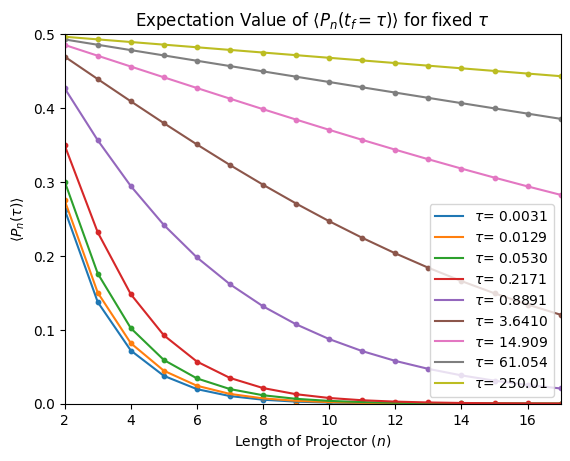

In [4]:
for i in range(0,Ntaus,6):
    plot(n_values,KZ_array[:,i],label=rf"$\tau$= {str(taus[i])[:6]}")
    scatter(n_values,KZ_array[:,i],s=10)

xlim(n_values[0],n_values[-1])
legend()
xlabel(r"Length of Projector ($n$)")
ylabel(r"$\langle P_n (\tau) \rangle$")
plt.title(r"Expectation Value of $\langle P_n (t_f=\tau) \rangle$ for fixed $\tau$")
#yscale("log")
ylim(0,.5)
plt.savefig("Expectation_value_vs_n_and_tau.pdf")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_67545/1374830759.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_67545/1374830759.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.5)


(np.float64(9.547085074206193e-06), 0.5)

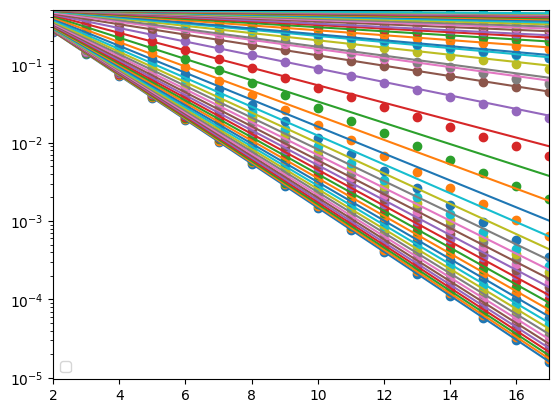

In [6]:

def exp_model(x, lam,A):
    return  A*2**(lam * x)

lam_list= []
A_list= []
for i in range(0,len(taus),1):
    # Example data
    x = np.array(n_values)
    y =KZ_array[:,i]
    # Fit
    popt, pcov = curve_fit(exp_model, x, y, p0=(1,1))
    lam_fit,A_fit = popt
    lam_list.append(lam_fit)
    A_list.append(A_fit)
    plt.scatter(x,y)
    plt.plot(x,exp_model(x,lam_fit,A_fit))
    j=i
    #plot(n_values,(1+2*p[j])/2*(1-p[j])**(n_values),ls=":",color="black")

xlim(n_values[0],n_values[-1])

plt.legend()
yscale("log")
ylim(0,.5)


This cell:

Claims that $\frac{1+2p(\tau)}{2}=A(\tau)$ and that $\lambda(\tau) \approx -2*p(\tau)$

While these are technically just approximate expressions, their closeness to the defect density is of particular note. This expression is particularily accurate at small and large $\tau$.

What I am struggling with is being able to *explain* where this comes from. 

$\braket{P_n (\tau)} = A(\tau) 2^{-\lambda(\tau) n } = (\frac{1+2p(\tau)}{2} ) 2^{-2p(\tau) n} = (\frac{1+\phi(\tau)}{2} ) 2^{-\phi(\tau)n}$

What is $\phi(\tau)?$ Well, I'm not totally sure. It's equal to 1 when $\tau=0$, it's equal to 0 when $\tau=\infty$. It's not exactly the defect density, it's twice it. It is related to the order parameter, via $\phi(\tau)=1-\braket{\sigma \sigma} = \delta(\tau)$. Hey, now we're getting somewhere. 
SO really, we have

$(\frac{1+\delta(\tau)}{2} ) 2^{-\delta(\tau)n}$ where $\delta(\tau)$ is the difference of the ground state and time evolved sigma sigma operators. Kind of like the thing we were already studying...

So maybe this is good. It gives a pretty good expression for $P_n(\tau)$, but do the terms mean anything? I really seem to believe that the first term, with the 1/2, represnts the fact that we are projecting to the even subspace. When we are reallly close to the ground state, we need to throw away half the terms. 

The second term is a bit of a thinker. Lets start witt the exponent.

$-\lambda n$ is a generic exponential decay over a characteristic length set by $\lambda$. When $\lambda=2p$ this sets the interpretation that $2 p n $ is twice the number of expected defects in a single chain. Maybe it's twice because there are two domain walls that get generated for each defect. I'm not totally sure.

So we have a # of defects, why do we multiply $2^{-\#}?$ It's firstly evident that we should probably think of this seperately from the first prefactor, that we said was purely due to the fact that we project to the even subspace. In principle, it should dissapear if we didn't do that(!?!?!?!?)

Let's talk from the perspective of max defects, where $2p=1$. Then we have $2^{-n}$. Lets think it over in terms of defects:

So lets say that in a chain of n particles we have n defects, that sets 2p=1. As a result, there is a coinflip odds that we project all n spins to the ground states. 

lets now say we're in some inbetween state, and 2p=1/2 p= 1/4. WE expect to find, I think, n/2 defects. 

SO our expectation value is made up of two parts. We have n/2 that ARE NOT defected, these should give us $(1+\delta)/2$, why? The number of defects going down means that we rare throwing away more states when we project to the positive x spins. Remember, it can adiabatically be broughht to minus x spins. 

The n/2 that ARE defected each have coin flips to be brought to the ground state, thus giving us a reasonable interpreation that 

$(\frac{1+\delta(\tau)}{2} ) 2^{-\delta(\tau)n}$'s two parts are first, a part that deals with the fact that we project to hte positive x values, and secondly the coin flip odds that our defects turn into + sigmas.

I personally like this interpretation a lot, but i think it might be tough to justify mathematically, but maybe not.

maybe the trick is to look into what it means for a defect particle to exist. It means that its in a mixed state, one part of it is still int he +z because it didnt' adiabatically follow the ground state, the other is in a super position of + and - because it did follwo teh ground state. Ultimately, since we take the ane xpectation over them all, that has to make sense. 


In [274]:
import kibble_zurek as kz
sigmaxx = np.empty(len(taus))
L = 100
for i in range(len(taus)):
    tau = taus[i]
    state = kz.state(L,tau,tau)

    sigmaxx[i] = kz.sigma_general([0,1],state)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:168: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


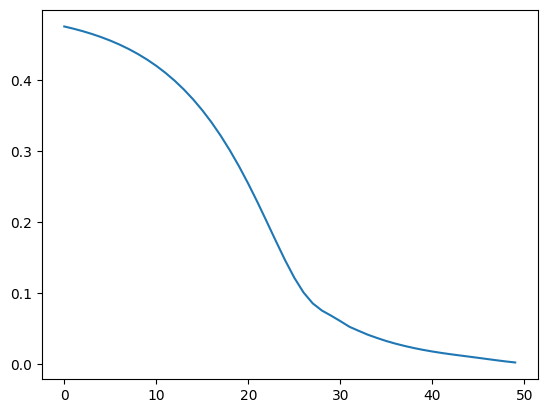

In [275]:
p = (1-sigmaxx)/2

plot(p)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_70732/3611336438.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


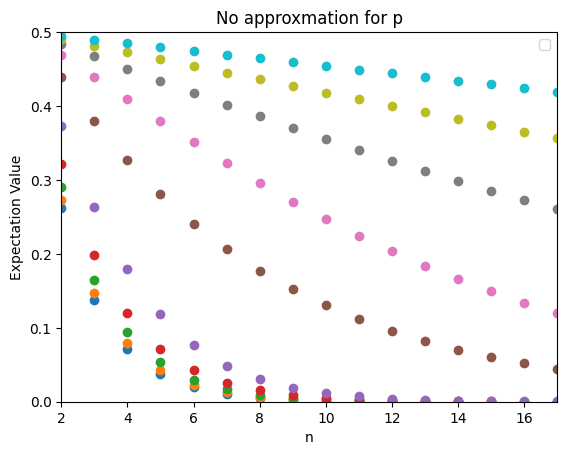

In [ ]:
p_test= 1/2/pi * 1/sqrt(2*taus)
phi = 2*p

for j in range(0,len(taus),5):

    #plot(n_values,1/2*(1+phi[j])*2**(-phi[j]*n_values),label= f"tau= {str(taus[j])[0:5]}")
    
    scatter(n_values, KZ_array[:,j])#,label=r"exact")
    plt.title(fr"No approxmation for p")
    legend()
    xlim(n_values[0],n_values[-1])
    ylim(0,0.5)
    xlabel("n")
    ylabel("Expectation Value")
plt.show()



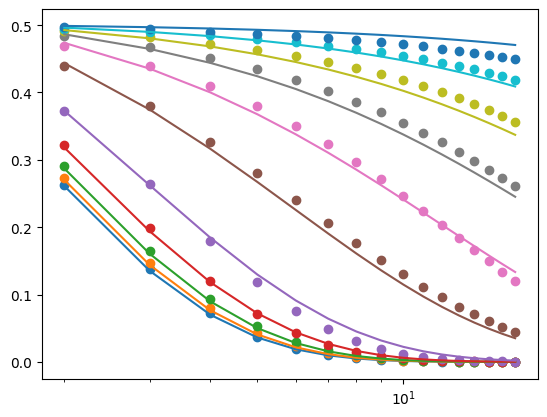

In [19]:


#plot(taus,p)
xscale("log")
for j in range(0,len(taus),5):
    plot(n_values,(1/2+p[j])*(1/4**(p[j]*n_values)))
    scatter(n_values, KZ_array[:,j])
j=-1
plot(n_values,(1/2+p[j])*(1/4**(p[j]*n_values)))
scatter(n_values, KZ_array[:,j])

In [148]:
import kibble_zurek as kz
from tqdm import tqdm
dat2=[]
for tau in tqdm(taus):
    state = kz.state(1000,tau,tau)
    dat2.append(kz.P_n(4,state))

dat2=np.array(dat2)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:20<00:00,  2.47it/s]


In [150]:
import kibble_zurek as kz
from tqdm import tqdm
dat3=[]
for tau in tqdm(taus):
    state = kz.state(1000,tau,tau)
    dat3.append(kz.P_n(8,state))

dat3=np.array(dat3)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:21<00:00,  2.37it/s]


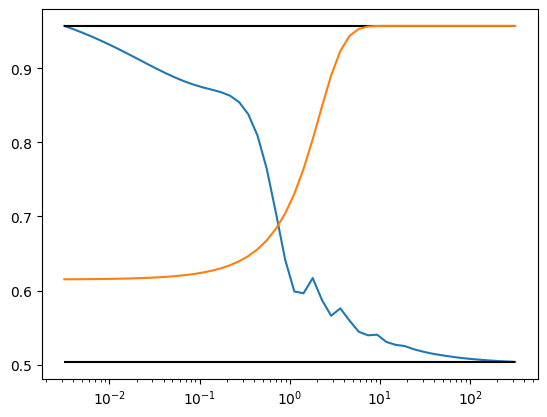

In [182]:
plot(taus,Alist)
x = max(Alist)
y= min(Alist)

xscale("log")
plt.hlines([x,y],taus[0],taus[-1],color="black")
sig = y + (x - y) / (1 + np.exp(-(taus - taus[len(taus)//2])))

plot(taus,sig)

In [426]:
# assumes taus and Alist are already defined

import numpy as np
import matplotlib.pyplot as plt

x = np.max(Alist)   # high
y = np.min(Alist)   # low

t = np.log10(taus)          # log-scale axis
tmin, tmax = t[0], t[-1]

# Constrain logistic in log-space to hug endpoints within eps
eps = 1e-3
zmin = np.log((1 - eps)/eps)
zmax = -zmin

k  = (zmax - zmin) / (tmax - tmin)
t0 = tmin - zmin / k

sigma = 1.0 / (1.0 + np.exp(-k * (t - t0)))  # low→high in log-space
sig   = (x - y) * sigma+x/1.9        # high→low in log-space
plt.xscale("log")
#plt.yscale("log")
plt.ylim(0.5,1.01)
plt.xlim(taus[0],taus[-1])

plt.plot(taus, Alist, label=r"$A(\tau)$")
plt.plot(taus, sig, label="sigmoid")
plt.hlines([1, y], taus[0], taus[-1], color="black", linewidth=0.8,ls="--")
plt.legend()
plt.show()
plt.vlines(1/2/pi/pi/pi,0,1)

NameError: name 'Alist' is not defined

# clacualtion of n defectrs

In [376]:
tau = .00000000001
L = 1000
state= kz.state(L,tau,tau)


In [377]:
abs((1-kz.G(1,state))/2)

np.float64(0.49999859875415936)

$p = \frac12 - \frac{1}{2L} \sum_{k>0} \left[\cos k \,\big( 1 - 2|v_k|^2 \big) + i \sin k \,\big( u_k v_k^{*} - u_k^{*} v_k \big) \right]$

$p = \frac12 - \frac{1}{4\pi} \int_{0}^{\pi} \mathrm{d}k \, \left[\cos k \,\big( 1 - 2|v_k|^2 \big) + i \sin k \,\big( u_k v_k^{*} - u_k^{*} v_k \big)\right]$

In [1]:
x= [0.333,1,1.84699,2.7834,3.72216,4.69218,5.67128,98.5646]
n =[1, 2, 3, 4, 5,6,7,100]

In [96]:
#import kblock_ising_model as kb
import kibble_zurek as kz
L = 1000
farawayspin= 10
indices = [0,1]
# indices2 = [0,2]
# indices3= [0,farawayspin]
# taus = np.logspace(-3,2.5,100)
# #k0 = kb.k_vals(L)
# #U0 = kb.U(k0,kz.g(1,1))


# nn = []
# nnn= []
# nnnn=[]
defects = []
for tau in taus:
    state = kz.state(L,tau,tau)

    defects.append((1-kz.sigma_general(indices,state))/2)
    # nn.append(kz.sigma_general(indices,state))
    # nnn.append(kz.sigma_general(indices2,state))
    # nnnn.append(kz.sigma_general(indices3,state))

defects=np.array(defects)




/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:168: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


(2.0576566096475712, 100.0)

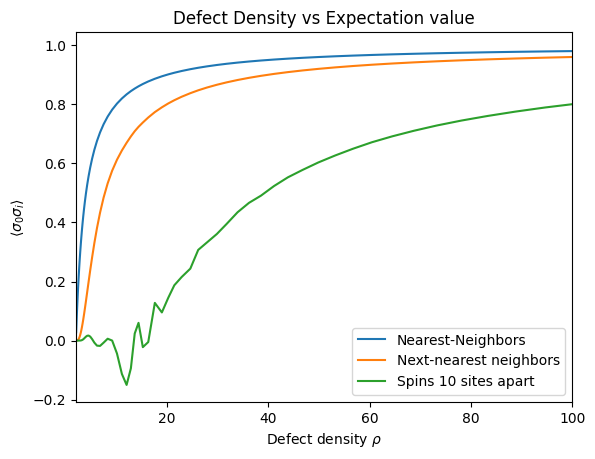

In [88]:
plot(1/defects,nn,label="Nearest-Neighbors")
plot(1/defects,nnn,label="Next-nearest neighbors")
plot(1/defects,nnnn,label=f"Spins {farawayspin} sites apart")
plt.xlabel(r"Defect density $\rho$")
plt.ylabel(r"$\langle \sigma_0 \sigma_i \rangle$")
plt.title("Defect Density vs Expectation value")
legend()
plt.xlim(1/defects[0],100)
#plt.ylim(-.2,1)
#plt.xscale("log")
#plot(defects)

In [94]:
KZ_array,taus,n_values = raw_data["KZ_Array"],raw_data["taus"],raw_data["n_values"]

In [153]:
corr = 1/defects

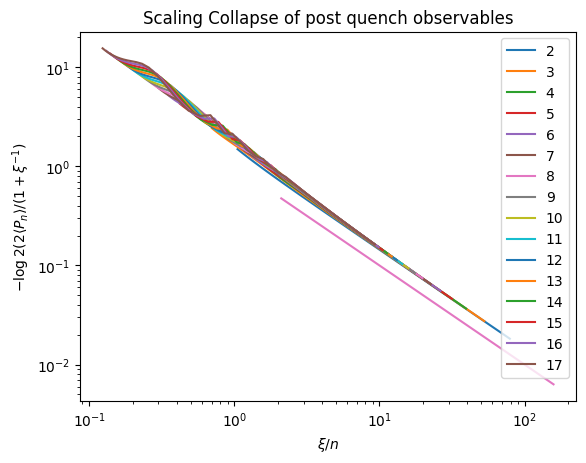

In [194]:
for ti, Y in enumerate(KZ_array):
    n= n_values[ti]
    if n%1==0:
        plot((corr/n),-np.log2(Y*2/(1+1/corr)),label=f"{n}")

plt.title("Scaling Collapse of post quench observables")
plt.xlabel(r"${\xi}/n$")
plt.ylabel(r"$-\log2(2\langle P_n \rangle/(1+\xi^{-1})$")
plt.plot(corr,-np.log2(2**(-1/corr)))
loglog()
legend()



In [210]:
L

1000

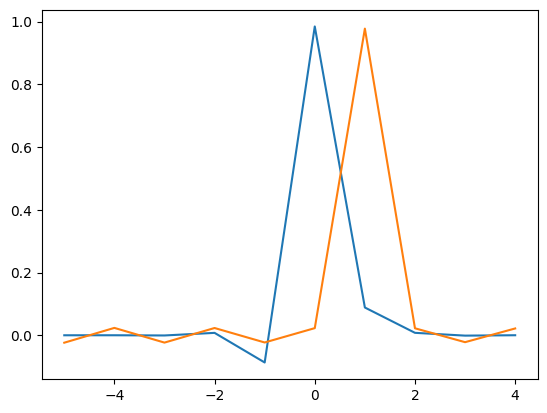

In [226]:
tau= .01
state= kz.state(L,tau,tau)
x= np.arange(-5,5)
plot(x,[kz.G(i,state) for i in x])
tau= 100
state= kz.state(L,tau,tau)
x= np.arange(-5,5)
plot(x,[kz.G(i,state) for i in x])

In [415]:
import numpy as np
L = 1000
G3_list  = []
G2_list  = []
G1_list  = []
G0_list  = []
Gm1_list = []
Gm2_list = []

for tau in taus:
    state = kz.state(L, tau, tau)
    G3_list.append(kz.G(3,  state))
    G2_list.append(kz.G(2,  state))
    G1_list.append(kz.G(1,  state))
    G0_list.append(kz.G(0,  state))
    Gm1_list.append(kz.G(-1, state))
    Gm2_list.append(kz.G(-2, state))

G3_array  = np.array(G3_list)
G2_array  = np.array(G2_list)
G1_array  = np.array(G1_list)
G0_array  = np.array(G0_list)
Gm1_array = np.array(Gm1_list)
Gm2_array = np.array(Gm2_list)



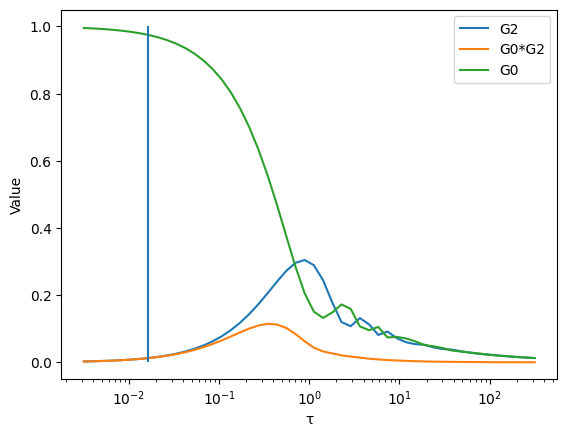

In [ ]:
# plt.plot(taus, G3_array,  label="G3")
plt.plot(taus, G2_array,  label="G2")
#plt.plot(taus, G1_array,  label="G1")
# plt.plot(taus, G1_array**2,  label="G1^2")
plt.plot(taus, G0_array*G2_array,  label="G0*G2")

plt.plot(taus,G0_array,  label="G0")
# plt.plot(taus, Gm1_array, label="G-1")
# plt.plot(taus, Gm2_array, label="G-2")

plt.xscale("log")
plt.xlabel("τ")
plt.ylabel("Value")
plt.legend()
#plt.show()


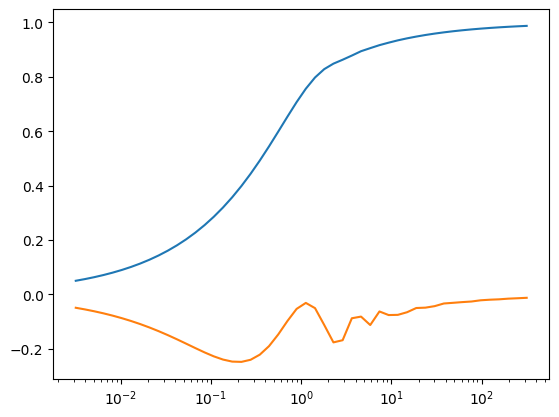

In [ ]:
plot(taus,G1_array)
plot(taus,Gm1_array)

xscale("log")

In [403]:
tau=.01
u, v,k = kz.state(100,tau,tau)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


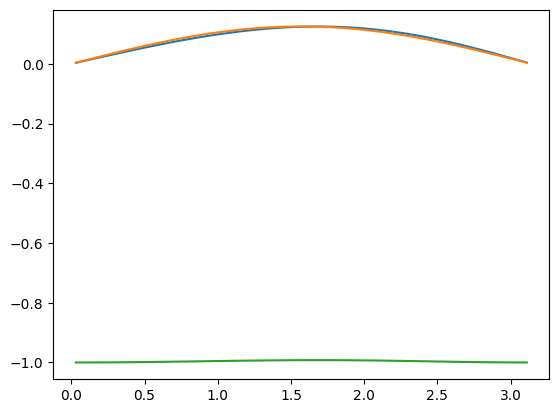

In [406]:
plot(k,np.abs(u))
plot(k,np.abs(sqrt(pi/2)*sqrt(tau)*sin(k)))
plot(k,(v))

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


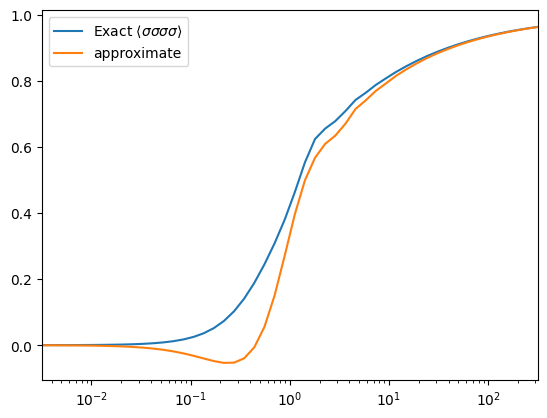

In [363]:
plot(taus,G1_array**3+
     2*G0_array*G1_array*G2_array
     +G0_array**2 *G3_array
     -G2_array**2*Gm1_array
     +G1_array*G3_array*Gm1_array,label=r"Exact $\langle \sigma \sigma \sigma \sigma \rangle$"
     )

plot(taus,G1_array**3,label="approximate"
     )

xlim(taus[0],taus[-1])

xscale("log")

legend()

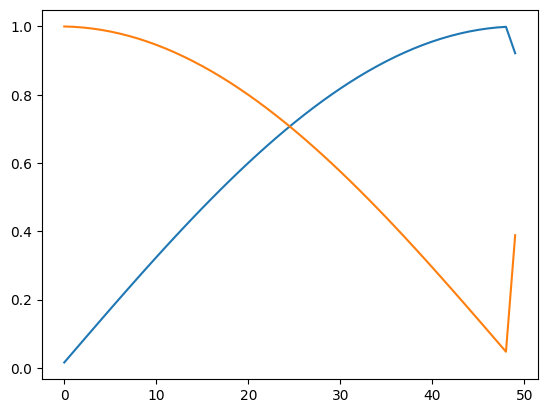

In [384]:
plot(abs(state[0]))
plot(abs(state[1]))

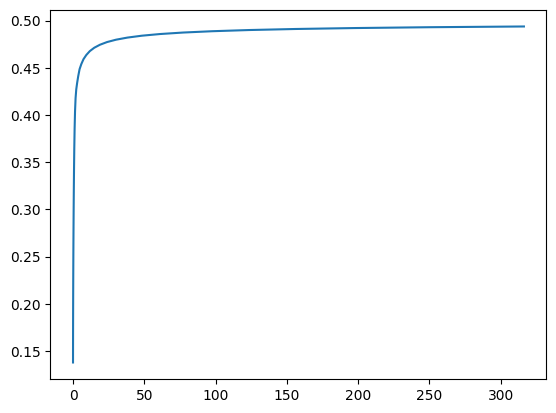

In [266]:
plot(taus,abs(1-defects)**2/2)

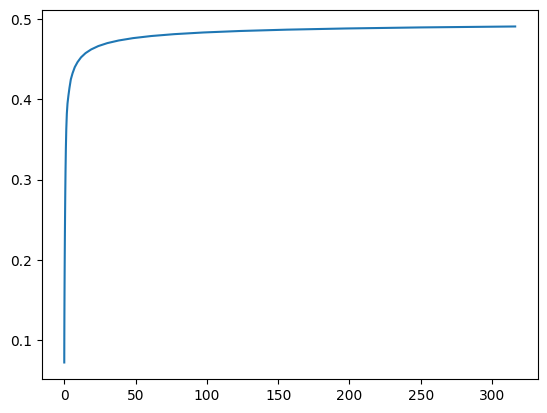

In [267]:
plot(taus,abs(1-defects)**3/2)

[]

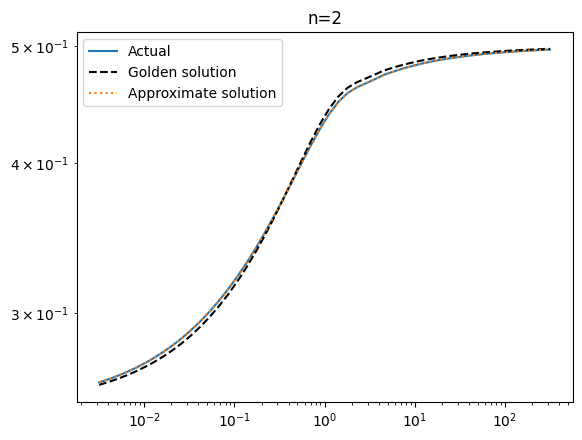

In [349]:
j=0

plot(taus,KZ_array[j,:],label="Actual")
plot(taus,(1/2+defects)*2**(-n_values[j]*2*defects),label=r"Golden solution",color="black",ls="--")
plot(taus,abs(1-defects)**(n_values[j]-1)/2,label="Approximate solution",ls=":")
plt.title(f"n={n_values[j]}")
legend()
loglog()

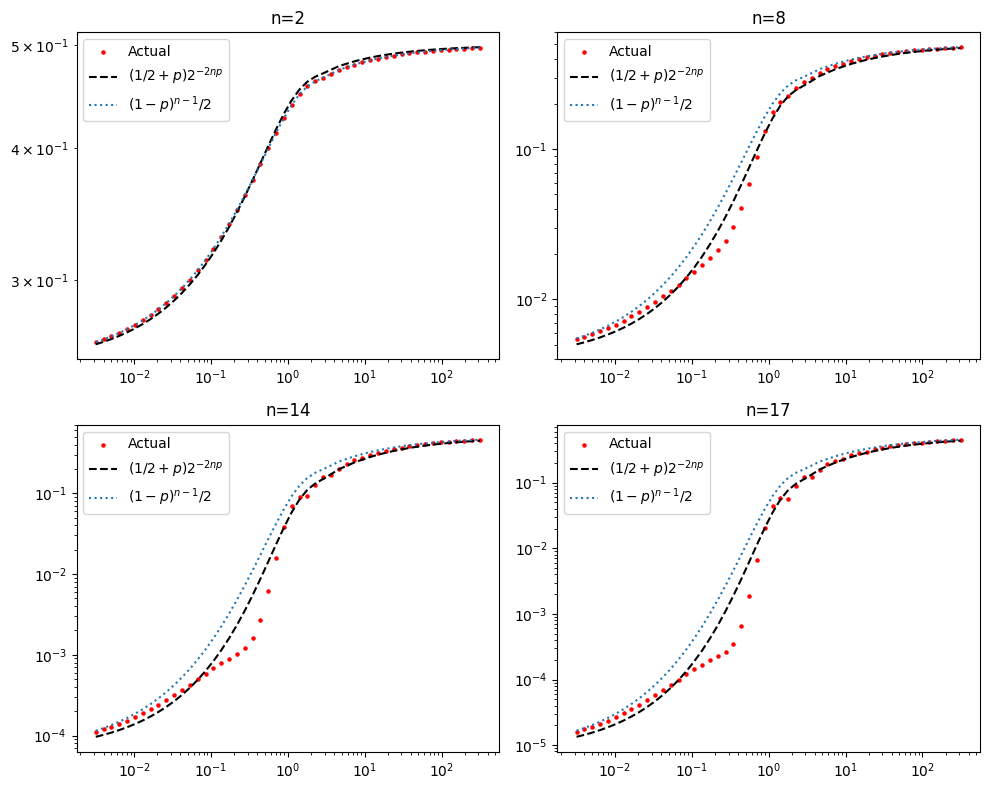

In [362]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

j_values = [0, 6, 12, -1]

for ax, j in zip(axes.flatten(), j_values):
    ax.scatter(taus, KZ_array[j, :], label="Actual",s=5,color="red")
    ax.plot(taus, (0.5 + defects) * 2**(-n_values[j] * 2 * defects),
            label=r"$(1/2+p)2^{-2np}$", color="black", ls="--")
    ax.plot(taus, (abs(1 - defects)**((n_values[j] - 1))/2 ),
            label=r"$(1-p)^{n-1}/2$", ls=":")
    ax.set_title(f"n={n_values[j]}")
    ax.legend()
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()


[]

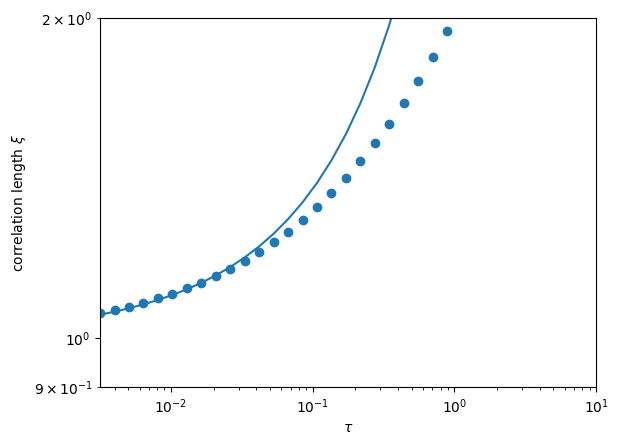

In [507]:
plot(taus,1/defects/2)
plt.ylim(0.9,2)
plt.ylabel(r"correlation length $\xi$")
plt.xlabel(r"$\tau$")
plt.xlim(taus[0],10)
plt.scatter(taus,1+taus**(1/2))
loglog()